# Hierarchical Deep Learning for Zooplankton Classification

## Executive Summary

This report develops and evaluates a hierarchical image-classification model for zooplankton and non-zooplankton particle categories. The approach combines a CNN image encoder with an RNN decoder that predicts taxonomy paths rather than only flat labels.

Key deliverables in this notebook include:
- hierarchy construction and sequence encoding
- class-balanced training with weighted sampling
- hyperparameter tuning with validation-based selection
- final leaf-level and parent-level performance assessment

In [ ]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
import ray
import seaborn as sns
import torch
import torch.nn as nn
import torchvision.models as models

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from torch.nn.utils.rnn import pad_sequence
from torchvision import transforms

from helpers import set_seed, ImageDataset

## 0. Environment and Reproducibility

This section imports required libraries, defines data paths, and fixes the random seed for reproducible training and evaluation.

In [ ]:
# Specify paths
data_directory = "Zooplankton-Data/"
data_subdirectories = ["Processed Data"]

# Specify other environment variables
SEED = 1
set_seed(SEED)


## 1. Taxonomy Design and Hierarchical Encoding

This section defines the target label space and constructs the taxonomy graph used for hierarchical decoding. Each class is mapped to a sequence from `<START>` to `<END>`, allowing the model to learn structured predictions.

In [ ]:
# Define the list of zooplankton classes we want to classify
ZOOPLANKTON_CLASSES = [
    "Bosminidae",
    "Daphnia",
    # "Holopedium",
    "Rotifer",
    "Nauplius_Copepod",
    "Cyclopoid",
    "Harpacticoid",
    "Calanoid",
    "Bubbles",
    "Exoskeleton",
    "Fiber_Hairlike",
    "Fiber_Squiggly",
    "Plant_Matter",
]
NUM_CLASSES = len(ZOOPLANKTON_CLASSES)


In [ ]:
# Define the hierarchical taxonomy structure mapping parents to children
TAXONOMY = {
    "Root": ["Yes", "No"],
    "Yes": ["Cladocera", "Rotifer_Group", "Copepoda"],
    "No": ["Bubble_Group", "Exoskeleton_Group", "Fiber", "Plant_Matter_Group"],
    "Cladocera": ["Bosminidae", "Daphnia"],
    "Copepoda": ["Calanoid", "Cyclopoid", "Harpacticoid", "Nauplius_Copepod"],
    "Rotifer_Group": ["Rotifer"],
    "Bubble_Group": ["Bubbles"],
    "Exoskeleton_Group": ["Exoskeleton"],
    "Fiber": ["Fiber_Hairlike", "Fiber_Squiggly"],
    "Plant_Matter_Group": ["Plant_Matter"],
}


In [ ]:
# Build vocabulary and mapping from class names to their hierarchical paths
def build_hierarchy_tools(taxonomy, flat_classes):
    # Build vocabulary starting with special tokens
    vocab = {"<PAD>": 0, "<START>": 1, "<END>": 2}
    next_idx = 3

    for parent, children in taxonomy.items():
        if parent not in vocab:
            vocab[parent] = next_idx
            next_idx += 1
        for child in children:
            if child not in vocab:
                vocab[child] = next_idx
                next_idx += 1

    # Recursive helper to find the path from root to a target node
    def get_path(node, target, current_path):
        if node == target:
            return current_path
        if node in taxonomy:
            for child in taxonomy[node]:
                res = get_path(child, target, current_path + [child])
                if res:
                    return res
        return None

    # Create lookup table mapping class names to tensor paths
    class_to_path = {}
    for class_name in flat_classes:
        raw_path = get_path("Root", class_name, [])

        if raw_path is None:
            raise ValueError(f"Class '{class_name}' is missing from the TAXONOMY dict!")

        full_path = ["<START>", "Root"] + raw_path + ["<END>"]
        class_to_path[class_name] = torch.tensor(
            [vocab[n] for n in full_path], dtype=torch.long
        )

    return vocab, class_to_path


vocab, class_to_path_map = build_hierarchy_tools(TAXONOMY, ZOOPLANKTON_CLASSES)
TOTAL_NODES = len(vocab)
print(f"Total nodes in Neural Network: {TOTAL_NODES}")

# Custom collate function to batch images and pad hierarchical path sequences
def hierarchical_collate_fn(batch):
    images = []
    paths = []

    # Collect images and corresponding hierarchical paths
    for img, label_idx in batch:
        images.append(img)

        class_name = ZOOPLANKTON_CLASSES[label_idx]

        seq = class_to_path_map[class_name]
        paths.append(seq)

    images = torch.stack(images)

    # Stack images and pad paths to the same length
    paths_padded = pad_sequence(paths, batch_first=True, padding_value=0)

    return images, paths_padded


## 2. Data Preparation and Sampling Strategy

Input images are standardized to a fixed resolution and normalized before model ingestion. Training uses stochastic augmentations and weighted sampling to mitigate class imbalance, while validation and test splits preserve label stratification.

The dataset is partitioned into training (60%), validation (20%), and test (20%) subsets. The validation split is used for hyperparameter selection, while the test split is reserved for final, unbiased performance reporting.

In [ ]:
basic_transforms = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ]
)

# Define augmentation pipeline for training data
aug_transforms = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(180),
    ]
)

NO_AUGMENT_CLASSES = ["Bubbles", "149um>"]

# Initialize the dataset with transforms and exclusions
dataset = ImageDataset(
    data_directory=data_directory,
    data_subdirectories=data_subdirectories,
    class_names=ZOOPLANKTON_CLASSES,
    max_class_size=8000,  # Changed from 15000 to 10000
    image_resolution=64,
    image_transforms=basic_transforms,
    aug_transforms=aug_transforms,
    ignore_classes=NO_AUGMENT_CLASSES,
    seed=SEED,
)

# Handle dataset targets if not directly accessible
try:
    all_labels = dataset.targets
except AttributeError:
    all_labels = [label for _, label in dataset]

# Split dataset into training and testing sets maintaining class distribution
train_val_split, test_split = train_test_split(
    np.arange(len(dataset)),
    test_size=0.2,
    stratify=all_labels,
    random_state=SEED,
)

# Get labels for the train_val subset to stratify the next split
train_val_labels = [all_labels[i] for i in train_val_split]

# Split train_val_split into training and validation sets
train_split, val_split = train_test_split(
    train_val_split,
    test_size=0.4,
    stratify=train_val_labels,
    random_state=SEED,
)

train_labels = [dataset.labels[i] for i in train_split]

# Calculate class weights to handle class imbalance
class_counts = {}
for lab in train_labels:
    class_counts[lab] = class_counts.get(lab, 0) + 1

print("Training Set Counts:", class_counts)

weight_per_class = {}
for class_idx in range(NUM_CLASSES):
    count = class_counts.get(class_idx, 0)
    if count > 0:
        weight_per_class[class_idx] = 1.0 / count
    else:
        weight_per_class[class_idx] = 0.0
        print(f"Warning: Class Index {class_idx} has 0 training samples!")

train_sample_weights = [weight_per_class[lab] for lab in train_labels]
train_sample_weights = torch.DoubleTensor(train_sample_weights)

# Create a weighted sampler to oversample minority classes
sampler = torch.utils.data.WeightedRandomSampler(
    weights=train_sample_weights,
    num_samples=len(train_sample_weights),
    replacement=True,
)

# Create the training data loader with the custom collate function
train_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(dataset, train_split),
    batch_size=64,
    sampler=sampler,
    shuffle=False,
    collate_fn=hierarchical_collate_fn,
)

val_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(dataset, val_split),
    batch_size=64,
    shuffle=False,
    collate_fn=hierarchical_collate_fn,
)

test_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(dataset, test_split),
    batch_size=64,
    shuffle=False,
    collate_fn=hierarchical_collate_fn,
)

## 3. Model Specification

The model combines a pre-trained CNN encoder (ResNet18 backbone) with an LSTM decoder that predicts node sequences in the taxonomy. This design allows the classifier to retain image-level feature quality while explicitly modeling hierarchical dependencies between labels.

### Detailed Architecture Walkthrough

The model treats classification as **sequence generation on a taxonomy** instead of a single flat class prediction.

For each image, the target is a token path such as:
`<START> -> Root -> Copepoda -> Calanoid -> <END>`

#### 1) CNN encoder (visual feature extraction)
- A pre-trained ResNet18 backbone processes each image.
- The final fully connected classifier layer is removed, leaving the convolutional feature extractor only.
- For a batch of images with shape `(B, C, H, W)`, the encoder output is flattened to `(B, F)`, where `F = resnet.fc.in_features`.

#### 2) Image-to-decoder state projection
- A linear layer maps encoder features from `F` to the decoder hidden size `H`.
- This projected vector initializes the LSTM hidden state: `h0 in R^(1 x B x H)`.
- The initial cell state is set to zeros with the same shape: `c0 in R^(1 x B x H)`.

#### 3) Token embedding and LSTM decoder
- Each hierarchy token index is converted to a dense embedding of size `E` via `nn.Embedding(num_classes, E)`.
- The LSTM consumes embedded tokens and predicts the next token in the hierarchy sequence.
- A final linear head maps each decoder output step from `H` to `num_classes` logits.

#### 4) Training mode (teacher forcing)
- Input tokens to the decoder are `captions[:, :-1]` (all tokens except the last).
- Targets are `captions[:, 1:]` (all tokens except the first).
- This creates next-token supervision at every time step.
- Cross-entropy is computed over flattened logits and targets, while ignoring PAD tokens (`ignore_index=0`).

#### 5) Inference mode (autoregressive decoding)
- Decoding starts from the `<START>` token.
- At each step:
  1. run one LSTM step
  2. project to logits
  3. choose argmax token
  4. feed predicted token back as next input
- The loop continues for `max_depth` steps, producing one predicted taxonomy path per image.

#### Why this structure is useful
- The encoder learns visual morphology from images.
- The decoder enforces path-like label structure, which supports biologically meaningful partial correctness (for example, correct parent group even when leaf class is wrong).
- This makes evaluation possible at both fine-grained (leaf) and coarse-grained (parent) levels.

In [ ]:
# Create reverse lookup for vocabulary
idx_to_word = {v: k for k, v in vocab.items()}


# Convert tensor indices back to a list of class names, handling special tokens
def decode_prediction(seq_tensor, idx_to_word):
    path = []
    for idx in seq_tensor:
        idx = idx.item()
        word = idx_to_word.get(idx, "<UNK>")

        if word == "<END>" or word == "<PAD>":
            break
        if word == "<START>":
            continue

        path.append(word)
    return path


In [ ]:
# Neural network combining a CNN encoder and RNN decoder for hierarchical classification
class HierarchicalCNNRNN(nn.Module):
    def __init__(self, num_classes, embed_size=128, hidden_size=256, num_layers=1):
        super(HierarchicalCNNRNN, self).__init__()

        # Use a pre-trained ResNet18 as the image encoder, freezing its weights
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        #for param in resnet.parameters():
        #  param.requires_grad = False


        modules = list(resnet.children())[:-1]
        self.cnn = nn.Sequential(*modules)

        # Project CNN features to match RNN hidden size
        self.cnn_to_rnn = nn.Linear(resnet.fc.in_features, hidden_size)

        # Embedding layer for label inputs
        self.embedding = nn.Embedding(num_classes, embed_size)

        # LSTM decoder to generate the hierarchy path
        self.rnn = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        # Output layer predicting the next node in the hierarchy
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, images, captions=None):
        batch_size = images.size(0)

        # Encode images to feature vectors
        features = self.cnn(images)

        features = features.view(features.size(0), -1)

        # Initialize RNN hidden state with image features
        h_0 = self.cnn_to_rnn(features).unsqueeze(0)
        c_0 = torch.zeros_like(h_0)

        if captions is not None:
            # Training mode: use teacher forcing with provided captions
            embeddings = self.embedding(captions[:, :-1])

            outputs, _ = self.rnn(embeddings, (h_0, c_0))

            predictions = self.fc(outputs)
            return predictions

        else:
            # Inference mode: autoregressively predict the next node in the hierarchy
            start_token_index = 1

            start_token = torch.tensor(
                [start_token_index] * batch_size, device=images.device
            ).unsqueeze(1)

            inputs = self.embedding(start_token)
            hidden = (h_0, c_0)
            outputs = []

            max_depth = 5
            for _ in range(max_depth):
                out, hidden = self.rnn(inputs, hidden)
                prediction = self.fc(out)

                predicted_class = prediction.argmax(2)
                outputs.append(predicted_class)

                inputs = self.embedding(predicted_class)

            return torch.cat(outputs, dim=1)

## 4. Training Procedure

### Detailed Training Protocol

#### Objective and token alignment
At training time, each sample provides a hierarchy token sequence of length `T` (including `<START>` and `<END>`). The decoder receives `captions[:, :-1]` and is trained to predict `captions[:, 1:]` (next-token prediction). This shifts the sequence by one step and provides supervision at every hierarchy level.

The loss is computed as cross-entropy over all valid (non-padding) token positions:

$$
\mathcal{L} = -\frac{1}{N_{valid}} \sum_{(b,t) \in \Omega} \log p_\theta\left(y_{b,t} \mid x_b, y_{b,<t}\right)
$$

where $\Omega$ is the set of non-PAD token indices and `ignore_index=0` ensures PAD tokens do not contribute to gradients.

#### Optimization setup
- Optimizer: Adam with learning rate selected by tuning.
- Backpropagation: gradients are computed from the sequence-level objective each mini-batch.
- Gradient clipping: `max_norm=1.0` is applied every update to reduce exploding gradients in the LSTM.
- Device handling: each batch is moved to GPU when available, otherwise CPU.

#### Epoch-level workflow
For each epoch in `train_model`:
1. Set model to training mode (`model.train()`).
2. Iterate over mini-batches from `train_loader`.
3. Run forward pass with teacher forcing (`model(images, captions)`).
4. Reshape logits and targets to align with cross-entropy input format.
5. Compute loss, zero gradients, run `loss.backward()`, clip gradients, and call `optimizer.step()`.
6. Accumulate batch losses and report epoch-average loss.

#### Early stopping rule
The trainer tracks `best_loss` and checks whether improvement exceeds a minimum threshold (`improvement`).
- If current loss is not at least that much better, a no-improvement counter increments.
- Training stops once the counter reaches `patience`.
- If sufficient improvement occurs, the counter resets and the best loss updates.

This rule avoids stopping due to tiny stochastic fluctuations while still limiting over-training.

#### Validation protocol
`validate_model` runs in evaluation mode (`model.eval()`) with `torch.no_grad()` to disable gradient tracking. It computes the same token-level loss on `val_loader`, providing a consistent metric for hyperparameter selection.

#### Why this procedure is appropriate
- Teacher forcing stabilizes sequence learning early in training.
- Token-level supervision propagates signal to both internal hierarchy decisions and final leaf predictions.
- Gradient clipping plus early stopping provides robust optimization behavior for CNN-RNN training on imbalanced biological image data.

### Forward Pass Tensor Shapes (Reference)

Assuming:
- batch size `B`
- embedding size `E`
- hidden size `H`
- vocabulary size `V = TOTAL_NODES`
- sequence length `T`

Then the key tensors are:
- image batch: `(B, C, H_img, W_img)`
- encoder features: `(B, F)`
- initial hidden/cell: `(1, B, H)`
- embedded decoder inputs (training): `(B, T-1, E)`
- decoder outputs: `(B, T-1, H)`
- token logits: `(B, T-1, V)`
- flattened logits for loss: `((B*(T-1)), V)`
- flattened targets for loss: `((B*(T-1)))`

This alignment explains why the code reshapes `outputs` and `captions[:, 1:]` before applying cross-entropy.

In [ ]:
class Trainer():
    def __init__(self, model, criterion, lr = 1e-5, max_epochs = 5, patience = 5, improvement = 1e-2):
        self.model = model
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        self.criterion = criterion
        self.lr = lr
        self.max_epochs = max_epochs
        self.patience = patience
        self.improvement = improvement

    def train_model(self):
        # Main training loop iterating over epochs
        best_loss = float('inf')
        no_improvement_count = 0

        for epoch in range(self.max_epochs):
            self.model.train()
            total_loss = 0

            for batch_idx, (images, captions) in enumerate(train_loader):
                # Move data to device
                images = images.to("cuda" if torch.cuda.is_available() else "cpu")
                captions = captions.to("cuda" if torch.cuda.is_available() else "cpu")

                # Forward pass
                outputs = self.model(images, captions)

                # Compute loss on flattened outputs
                outputs_flat = outputs.reshape(-1, TOTAL_NODES)
                targets_flat = captions[:, 1:].reshape(-1)

                loss = self.criterion(outputs_flat, targets_flat)

                # Backpropagation and optimization with gradient clipping
                self.optimizer.zero_grad()
                loss.backward()

                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

                self.optimizer.step()
                total_loss += loss.item()

            avg_loss = total_loss / len(train_loader)
            print(f"Epoch [{epoch + 1}/{self.max_epochs}], Loss: {avg_loss:.4f}")

            if avg_loss >= best_loss - self.improvement:
                no_improvement_count += 1
                if no_improvement_count >= self.patience:
                    print(f"Early stopping at epoch {epoch + 1} due to insufficient improvement in loss.")
                    break
            else:
                no_improvement_count = 0
                best_loss = avg_loss

    def validate_model(self):
        self.model.eval()
        total_loss = 0
        with torch.no_grad():
            for batch_idx, (images, captions) in enumerate(val_loader):
                # Move data to device
                images = images.to("cuda" if torch.cuda.is_available() else "cpu")
                captions = captions.to("cuda" if torch.cuda.is_available() else "cpu")

                # Forward pass
                outputs = self.model(images, captions)

                # Compute loss on flattened outputs
                outputs_flat = outputs.reshape(-1, TOTAL_NODES)
                targets_flat = captions[:, 1:].reshape(-1)

                loss = self.criterion(outputs_flat, targets_flat)
                total_loss += loss.item()

            avg_loss = total_loss / len(val_loader)

        return avg_loss


## 5. Hyperparameter Tuning

A structured search is used to select hyperparameters that minimize validation loss while maintaining stable convergence and reasonable training cost.

### Detailed Tuning Methodology

### Search objective
Hyperparameter tuning is used to identify the model configuration that minimizes validation loss under the same hierarchical sequence objective used in training. The selected model should generalize well to unseen samples while maintaining stable optimization behavior.

### Candidate space and rationale
The grid search explores combinations of:
- Embedding size: controls representational capacity for hierarchy tokens.
- Hidden size: controls decoder memory and sequence modeling power.
- Learning rate: controls update magnitude and convergence speed.
- Maximum epochs: controls optimization budget.
- Patience and minimum improvement: control early-stopping sensitivity.

These choices balance expressiveness and training stability. Larger embedding and hidden dimensions can improve fit but increase computational cost and overfitting risk; early-stopping settings counterbalance that risk.

### Procedure executed in this notebook
For each hyperparameter tuple, the tuning loop performs:
1. Instantiate a fresh HierarchicalCNNRNN with the candidate dimensions.
2. Train with the Trainer class on the training partition.
3. Evaluate average token-level validation loss on the validation partition.
4. Compare against the current best validation loss.
5. Save the tuple if it improves the objective.

Using full reinitialization each trial prevents information leakage across configurations and ensures comparability.

### Model selection criterion
The primary selection metric is validation loss. Formally, choose

$$
\hat{\lambda} = \arg\min_{\lambda \in \Lambda} \; \mathcal{L}_{val}(\lambda)
$$

where $\lambda$ is a hyperparameter tuple and $\Lambda$ is the evaluated grid.

### Computational considerations
Grid size grows multiplicatively with each list length. If each trial takes time $t$, total runtime is approximately

$$
T_{total} \approx |E| \cdot |H| \cdot |LR| \cdot |M| \cdot |P| \cdot |I| \cdot t
$$

Practical implications:
- Keep the first pass coarse (small lists) to identify promising regions.
- Refine around strong candidates with a second, narrower search.
- Track wall-clock time per trial for transparent reporting.

### Reporting tuning outcomes
For a professional write-up, summarize all tested configurations in a compact table with columns such as embedding size, hidden size, learning rate, max epochs, patience, improvement threshold, validation loss, and training time.

Then report:
1. Best configuration and its validation loss.
2. Relative difference between top candidates.
3. Final chosen setting used for retraining on train plus validation data.

### Potential improvements for future experiments
- Replace exhaustive grid search with random or Bayesian optimization for better sample efficiency.
- Use cross-validation or repeated splits for more robust model ranking.
- Add secondary tie-breakers such as macro F1 or parent-level accuracy when validation losses are very close.

In [ ]:
class HPTuner():
    def __init__(self, embed_size_list, hidden_size_list,
                 lr_list, max_epochs_list, patience_list, improvement_list):
      self.embed_size_list = embed_size_list
      self.hidden_size_list = hidden_size_list
      self.lr_list = lr_list
      self.max_epochs_list = max_epochs_list
      self.patience_list = patience_list
      self.improvement_list = improvement_list
      self.criterion = nn.CrossEntropyLoss(ignore_index=0)
      self.best_hyperparams = None

    def tune_model(self):
      best_hyperparams = None
      best_loss = float('inf')
      for e, h, l, m, p, i in itertools.product(self.embed_size_list, self.hidden_size_list,
                                                   self.lr_list, self.max_epochs_list,
                                                   self.patience_list, self.improvement_list):
        print(f"Fitting model with hyperparameters: {e, h, l, m, p, i}")
        model = HierarchicalCNNRNN(TOTAL_NODES, embed_size = e, hidden_size = h, num_layers = 1).to("cuda" if torch.cuda.is_available() else "cpu")
        trainer = Trainer(model, self.criterion, lr = l, max_epochs = m, patience = p, improvement = i)
        trainer.train_model()
        val_loss = trainer.validate_model()
        print(f"Validation loss: {val_loss}")
        if val_loss < best_loss:
          best_loss = val_loss
          best_hyperparams = (e, h, l, m, p, i)

      self.best_hyperparams = best_hyperparams

    def get_optimal_hyperparams(self):
      return self.best_hyperparams

In [ ]:
tuner = HPTuner(embed_size_list=[128, 256, 512],
                hidden_size_list=[128, 256, 512],
                lr_list=[1e-3],
                max_epochs_list=[50],
                patience_list=[10],
                improvement_list=[3e-3])

tuner.tune_model()

best_hyperparams = tuner.get_optimal_hyperparams()


In [42]:
best_hyperparams = [512, 512, 1e-4, 100, 5, 0.03]

## 6. Final Model Training

Using the selected hyperparameters, the model is retrained on the combined training and validation partitions to maximize data utilization before final testing. The objective remains hierarchy-sequence prediction with token-level supervision.

In [ ]:
# Initialize model with total nodes in the vocabulary
model = HierarchicalCNNRNN(num_classes=TOTAL_NODES, embed_size=best_hyperparams[0], hidden_size=best_hyperparams[1]).to("cuda" if torch.cuda.is_available() else "cpu")
# Set up optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=best_hyperparams[2])
# Use CrossEntropyLoss, ignoring padding tokens
criterion = nn.CrossEntropyLoss(ignore_index=0)


train_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(dataset, np.hstack([train_split, val_split])),
    batch_size=64,
    shuffle=False,
    collate_fn=hierarchical_collate_fn,
    pin_memory=True,
    num_workers=4
)

#NUM_EPOCHS = best_hyperparams[3]
NUM_EPOCHS = 50
PATIENCE = best_hyperparams[4]
IMPROVEMENT = best_hyperparams[5]

# Main training loop iterating over epochs
print(f"Starting Training for {NUM_EPOCHS} epochs...")
# Main training loop iterating over epochs
best_loss = float('inf')
no_improvement_count = 0

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    for batch_idx, (images, captions) in enumerate(train_loader):
        # Move data to device
        images = images.to("cuda" if torch.cuda.is_available() else "cpu")
        captions = captions.to("cuda" if torch.cuda.is_available() else "cpu")

        # Forward pass
        outputs = model(images, captions)

        # Compute loss on flattened outputs
        outputs_flat = outputs.reshape(-1, TOTAL_NODES)
        targets_flat = captions[:, 1:].reshape(-1)

        loss = criterion(outputs_flat, targets_flat)

        # Backpropagation and optimization with gradient clipping
        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}], Loss: {avg_loss:.4f}")


Starting Training for 50 epochs...
Epoch [1/50], Loss: 0.3335
Epoch [2/50], Loss: 0.0841
Epoch [3/50], Loss: 0.0643
Epoch [4/50], Loss: 0.0544
Epoch [5/50], Loss: 0.0490
Epoch [6/50], Loss: 0.0456
Epoch [7/50], Loss: 0.0416
Epoch [8/50], Loss: 0.0408
Epoch [9/50], Loss: 0.0384
Epoch [10/50], Loss: 0.0374
Epoch [11/50], Loss: 0.0356
Epoch [12/50], Loss: 0.0340
Epoch [13/50], Loss: 0.0330
Epoch [14/50], Loss: 0.0323
Epoch [15/50], Loss: 0.0313
Epoch [16/50], Loss: 0.0310
Epoch [17/50], Loss: 0.0302
Epoch [18/50], Loss: 0.0286
Epoch [19/50], Loss: 0.0289
Epoch [20/50], Loss: 0.0277
Epoch [21/50], Loss: 0.0270
Epoch [22/50], Loss: 0.0264
Epoch [23/50], Loss: 0.0257
Epoch [24/50], Loss: 0.0254
Epoch [25/50], Loss: 0.0255
Epoch [26/50], Loss: 0.0248
Epoch [27/50], Loss: 0.0247
Epoch [28/50], Loss: 0.0238
Epoch [29/50], Loss: 0.0237
Epoch [30/50], Loss: 0.0230
Epoch [31/50], Loss: 0.0229
Epoch [32/50], Loss: 0.0228
Epoch [33/50], Loss: 0.0215
Epoch [34/50], Loss: 0.0219
Epoch [35/50], Loss: 0

Exception in thread Thread-47 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_

KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), "../model/cnn_rnn_weights.pt")


## 7. Evaluation Framework

Performance is analyzed at two levels:
- **Leaf-level:** exact class prediction quality for end categories
- **Parent-level:** major group prediction quality to assess hierarchical consistency

Both textual metrics (precision/recall/F1) and normalized confusion matrices are used to characterize model behavior.

In [44]:
# Run inference on the test set and compute classification metrics
def evaluate_model(model, loader, idx_to_word):
    # Run model in inference mode
    model.eval()

    y_true_leaves = []
    y_pred_leaves = []
    y_pred_paths = []

    print("Starting Evaluation...")

    with torch.no_grad():
        for images, captions in loader:
            images = images.to("cuda" if torch.cuda.is_available() else "cpu")
            captions = captions.to("cuda" if torch.cuda.is_available() else "cpu")

            preds = model(images, captions=None)

            # Decode ground truth and predicted paths to find the leaf nodes
            for i in range(len(images)):
                gt_path = decode_prediction(captions[i], idx_to_word)
                if not gt_path:
                    continue
                gt_leaf = gt_path[-1]

                pred_path = decode_prediction(preds[i], idx_to_word)

                if len(pred_path) < 1:
                    pred_leaf = "<EMPTY>"
                else:
                    pred_leaf = pred_path[-1]

                y_true_leaves.append(gt_leaf)
                y_pred_leaves.append(pred_leaf)
                y_pred_paths.append(pred_path)

    # Compute and print classification report
    print("\n--- Classification Report ---")
    print(classification_report(y_true_leaves, y_pred_leaves))

    return y_true_leaves, y_pred_leaves, y_pred_paths


true_labels, pred_labels, pred_paths = evaluate_model(model, test_loader, idx_to_word)

Starting Evaluation...

--- Classification Report ---
                  precision    recall  f1-score   support

      Bosminidae       0.99      0.94      0.96       605
         Bubbles       1.00      0.99      1.00       972
        Calanoid       0.96      0.90      0.93      1600
       Cyclopoid       0.91      0.94      0.93      1600
         Daphnia       0.97      0.99      0.98       700
     Exoskeleton       0.94      0.93      0.94       229
  Fiber_Hairlike       0.96      0.97      0.96      1058
  Fiber_Squiggly       0.98      0.97      0.97      1291
    Harpacticoid       0.78      0.88      0.82       345
Nauplius_Copepod       0.96      0.98      0.97      1210
    Plant_Matter       0.93      0.95      0.94       111
         Rotifer       0.98      0.94      0.96       610

        accuracy                           0.95     10331
       macro avg       0.94      0.95      0.95     10331
    weighted avg       0.95      0.95      0.95     10331



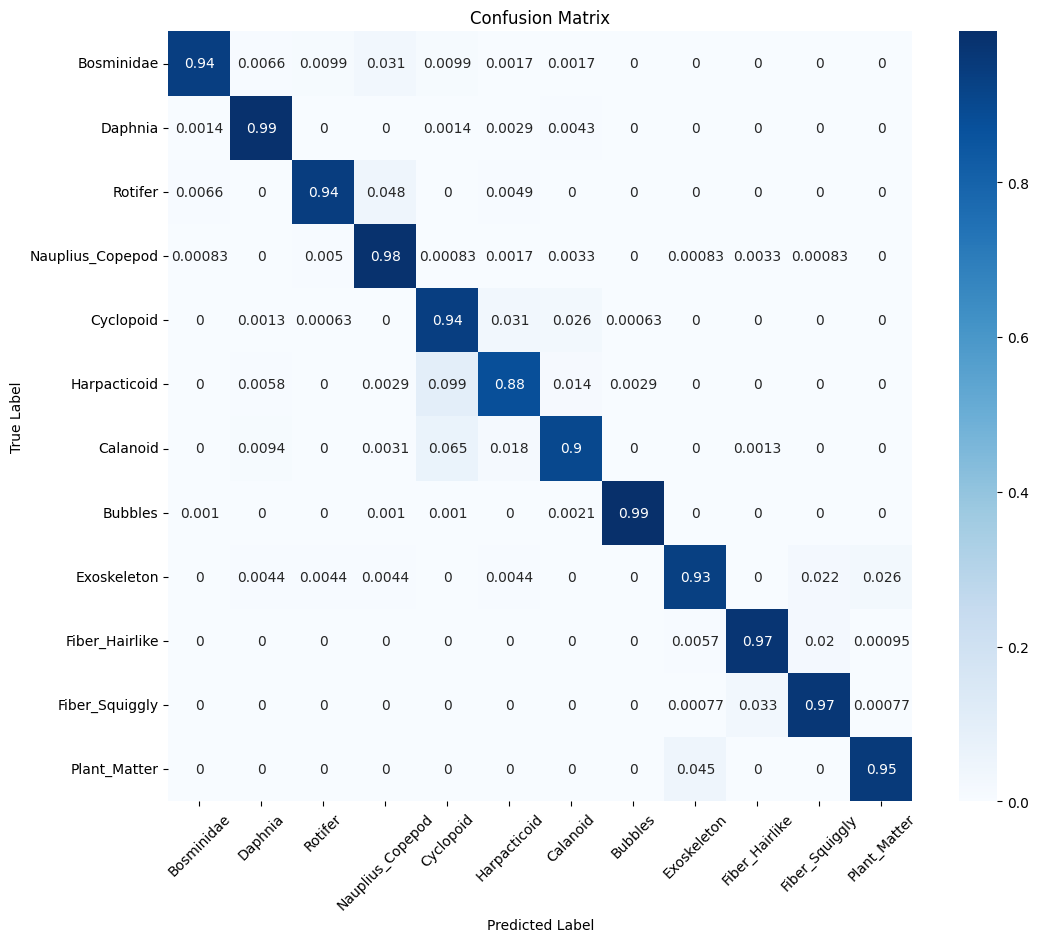

In [45]:
# Ensure predictions are available
if 'true_labels' not in locals() or 'pred_labels' not in locals():
    print("Running evaluation to get predictions...")
    true_labels, pred_labels = evaluate_model(model, test_loader, idx_to_word)

# Generate Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels, labels=ZOOPLANKTON_CLASSES, normalize='true')

# Plot Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    xticklabels=ZOOPLANKTON_CLASSES,
    yticklabels=ZOOPLANKTON_CLASSES,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

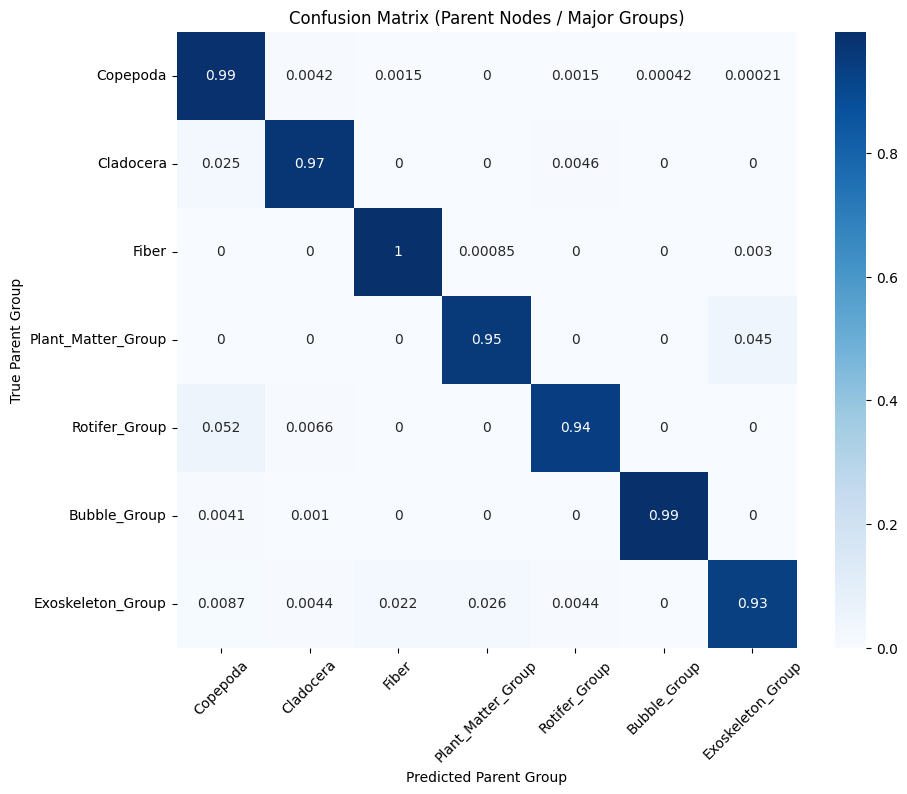

In [46]:
# Build a mapping from Leaf -> Immediate Parent (Major Group)
# We limit parents to those relevant to our valid leaves
valid_leaves = set(ZOOPLANKTON_CLASSES)
leaf_to_parent_map = {}

for parent, children in TAXONOMY.items():
    for child in children:
        if child in valid_leaves:
            leaf_to_parent_map[child] = parent

def get_parent_label(label):
    """Maps a label (leaf or otherwise) to its parent group if applicable."""
    return leaf_to_parent_map.get(label, label)

# Map predictions and ground truth to parents
true_parents = [get_parent_label(l) for l in true_labels]
# Note: pred_labels might contain things that are ALREADY parents if the hierarchy stopped early
pred_parents = [path[-2] for path in pred_paths]

# Get unique parent classes for the matrix
# Using set to get unique values, then sorting
parent_classes = list(set(true_parents + pred_parents))

# Generate Confusion Matrix
cm_parents = confusion_matrix(true_parents, pred_parents, labels=parent_classes, normalize='true')

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_parents,
    annot=True,
    cmap="Blues",
    xticklabels=parent_classes,
    yticklabels=parent_classes,
)
plt.xlabel("Predicted Parent Group")
plt.ylabel("True Parent Group")
plt.title("Confusion Matrix (Parent Nodes / Major Groups)")
plt.xticks(rotation=45)
plt.show()

In [47]:
print(classification_report(true_parents, pred_parents))

                    precision    recall  f1-score   support

      Bubble_Group       1.00      0.99      1.00       972
         Cladocera       0.98      0.97      0.97      1305
          Copepoda       0.99      0.99      0.99      4755
 Exoskeleton_Group       0.94      0.93      0.94       229
             Fiber       0.99      1.00      1.00      2349
Plant_Matter_Group       0.93      0.95      0.94       111
     Rotifer_Group       0.98      0.94      0.96       610

          accuracy                           0.99     10331
         macro avg       0.97      0.97      0.97     10331
      weighted avg       0.99      0.99      0.99     10331



## 8. Conclusion

The tuned CNN-RNN model performs strongly for hierarchical zooplankton classification, with high accuracy on most leaf classes and very strong separation at the parent-group level. Remaining errors are concentrated in biologically similar taxa, suggesting that future gains will likely come from targeted augmentation and finer-grained feature learning for difficult class pairs.

The model performs worst on harpacticoids at the leaf level. However, at the parent level it achieves 99% accuracy within the Copepoda group. This indicates that the model is reliably identifying copepod images but still struggles to assign the correct copepod subtype. This highlights a key advantage of the hierarchical approach: it reveals where errors occur in the taxonomy and provides insight into the model's internal decision structure.